In [ ]:
from google.colab import files
uploaded = files.upload('/content/Crime_Data_from_2020_to_Present.parquet')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap


In [ ]:
df = pd.read_parquet("/content/Crime_Data_from_2020_to_Present.parquet")
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,occ_year,occ_month,occ_date,occ_day
0,211507896,2021-04-11,2020-11-07,08:45:00,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,7800 BEEMAN AV,34.2124,-118.4092,2020,Nov,7,Sat
1,201516622,2020-10-21,2020-10-18,18:45:00,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,ATOLL AV,34.1993,-118.4203,2020,Oct,18,Sun
2,240913563,2024-12-10,2020-10-30,12:40:00,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,14600 SYLVAN ST,34.1847,-118.4509,2020,Oct,30,Fri
3,210704711,2020-12-24,2020-12-24,13:10:00,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,6000 COMEY AV,34.0339,-118.3747,2020,Dec,24,Thu
4,201418201,2020-10-03,2020-09-29,18:30:00,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,4700 LA VILLA MARINA,33.9813,-118.4350,2020,Sep,29,Tue


In [ ]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   DR_NO           1004991 non-null  int64         
 1   Date Rptd       1004991 non-null  datetime64[ns]
 2   DATE OCC        1004991 non-null  datetime64[ns]
 3   TIME OCC        1004991 non-null  object        
 4   AREA            1004991 non-null  int64         
 5   AREA NAME       1004991 non-null  object        
 6   Rpt Dist No     1004991 non-null  int64         
 7   Part 1-2        1004991 non-null  int64         
 8   Crm Cd          1004991 non-null  int64         
 9   Crm Cd Desc     1004991 non-null  object        
 10  Mocodes         1004991 non-null  object        
 11  Vict Age        1004991 non-null  int64         
 12  Vict Sex        1004991 non-null  object        
 13  Vict Descent    1004991 non-null  object        
 14  Premis Cd       10

,DR_NO,Date Rptd,DATE OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,LAT,LON,occ_year,occ_date
count,1.004991e+06,1004991,1004991,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06
mean,2.202215e+08,2022-05-25 22:02:46.977017344,2022-05-13 17:50:37.556754688,1.069174e+01,1.115633e+03,1.400348e+00,5.001568e+02,2.891706e+01,3.056153e+02,1.185118e+02,4.999119e+02,3.399821e+01,-1.180909e+02,2.021879e+03,1.534594e+01
min,8.170000e+02,2020-01-01 00:00:00,2020-01-01 00:00:00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.186676e+02,2.020000e+03,1.000000e+00
25%,2.106169e+08,2021-04-21 00:00:00,2021-04-06 00:00:00,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,0.000000e+00,3.310000e+02,3.401470e+01,-1.184305e+02,2.021000e+03,7.000000e+00
50%,2.209159e+08,2022-06-08 00:00:00,2022-05-26 00:00:00,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,0.000000e+00,4.420000e+02,3.405890e+01,-1.183225e+02,2.022000e+03,1.500000e+01
75%,2.311103e+08,2023-07-04 00:00:00,2023-06-22 00:00:00,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,3.070000e+02,6.260000e+02,3.416490e+01,-1.182739e+02,2.023000e+03,2.300000e+01
max,2.521041e+08,2025-06-04 00:00:00,2025-05-29 00:00:00,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,5.160000e+02,9.560000e+02,3.433430e+01,0.000000e+00,2.025000e+03,3.100000e+01
std,1.319718e+07,NaN,NaN,6.110255e+00,6.111605e+02,4.899691e-01,2.052731e+02,2.199272e+01,2.193038e+02,1.845896e+02,2.050791e+02,1.610713e+00,5.582386e+00,1.315051e+00,8.950559e+00


In [ ]:
df['Year'] = df['DATE OCC'].dt.year
df['Month'] = df['DATE OCC'].dt.month
df['Hour'] = pd.to_datetime(df['TIME OCC'], format='%H:%M:%S', errors='coerce').dt.hour

df.dropna(inplace=True)

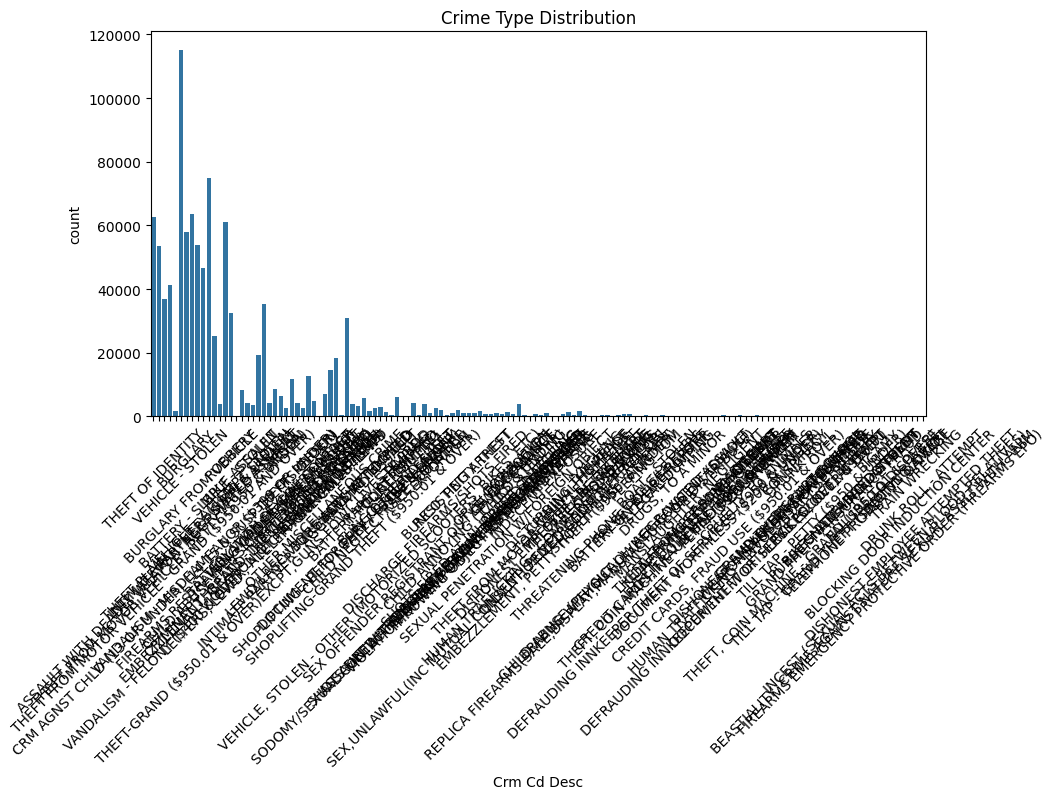

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Crm Cd Desc')
plt.xticks(rotation=45)
plt.title("Crime Type Distribution")
plt.show()

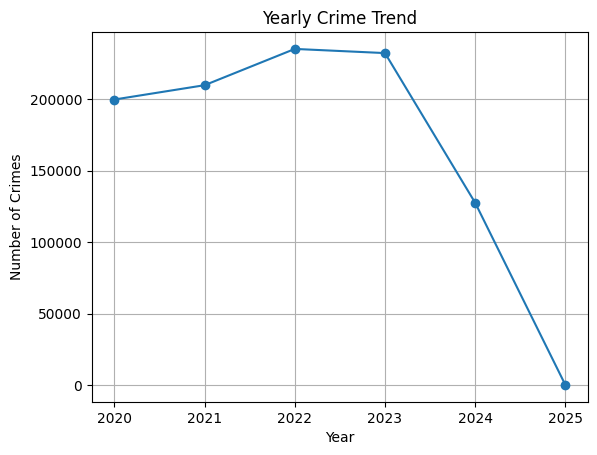

In [ ]:
yearly = df.groupby('Year').size()

plt.plot(yearly.index, yearly.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.title("Yearly Crime Trend")
plt.grid()
plt.show()


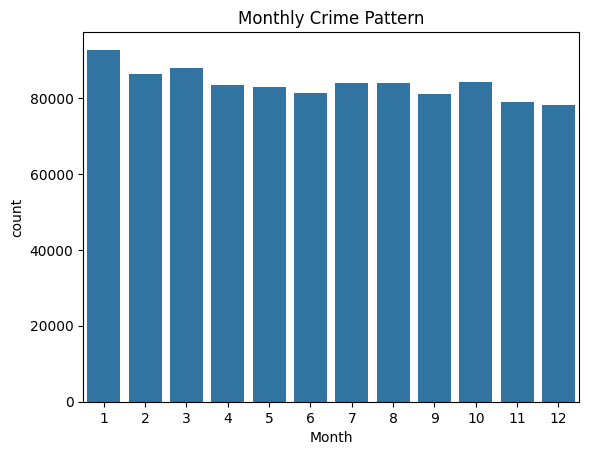

In [ ]:
sns.countplot(x='Month', data=df)
plt.title("Monthly Crime Pattern")
plt.show()


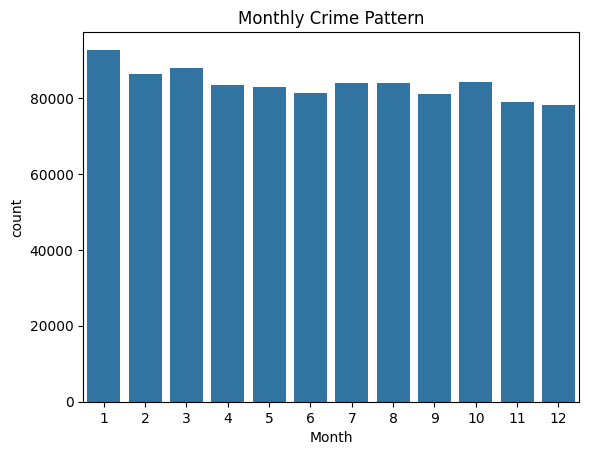

In [ ]:
sns.countplot(x='Month', data=df)
plt.title("Monthly Crime Pattern")
plt.show()


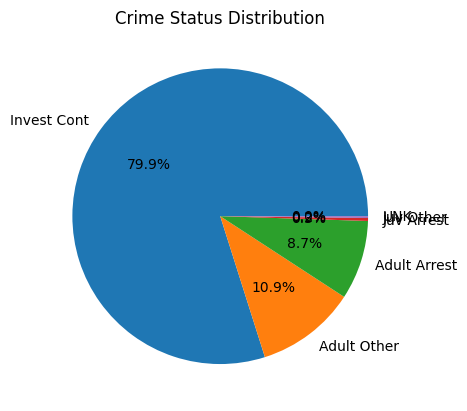

In [ ]:
df['Status Desc'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Crime Status Distribution")
plt.ylabel("")
plt.show()

In [ ]:
crime_map = folium.Map(
    location=[df['LAT'].mean(), df['LON'].mean()],
    zoom_start=11
)

heat_data = df[['LAT', 'LON']].values.tolist()
HeatMap(heat_data).add_to(crime_map)

crime_map

In [ ]:
high_risk = df.groupby('LOCATION').size().sort_values(ascending=False).head(10)
high_risk

,0
LOCATION,
800 N ALAMEDA ST,2598
700 S FIGUEROA ST,1711
100 THE GROVE DR,1688
10200 SANTA MONICA BL,1657
6TH ST,1585
11800 SANTA MONICA BL,1526
7TH ST,1502
9300 TAMPA AV,1452
7TH,1447
